In [70]:
import time
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist

from sklearn.preprocessing import StandardScaler, PolynomialFeatures, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, confusion_matrix, classification_report)
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score
from sklearn.pipeline import Pipeline

from cvxopt import matrix, solvers
from itertools import combinations

# Suppress cvxopt output
solvers.options['show_progress'] = False

In [71]:
print("Loading data...")
y_raw = pd.read_csv("labels.csv", index_col=0).to_numpy().flatten()
le = LabelEncoder()
y = le.fit_transform(y_raw)
X = pd.read_csv("fused.csv", index_col=0).to_numpy() 
X_image = pd.read_csv("image.csv", index_col=0).to_numpy()
X_text = pd.read_csv("text.csv", index_col=0).to_numpy()
X_meta = pd.read_csv("meta.csv", index_col=0).to_numpy().astype(float)
X_fused = pd.read_csv("fused.csv", index_col=0).to_numpy()
print(f"Dataset shape: {X.shape}")
print(f"Number of classes: {len(np.unique(y))}")
print(f"Classes: {le.classes_}")
print(f"Samples per class: {pd.Series(y_raw).value_counts().to_dict()}")

Loading data...
Dataset shape: (3071, 354)
Number of classes: 5
Classes: ['apple' 'banana' 'mandarin' 'onion' 'potato']
Samples per class: {'potato': 692, 'onion': 638, 'mandarin': 628, 'apple': 609, 'banana': 504}


### Feature Sets Comparison


Feature dimensions:
  Image: 19 features
  Text: 300 features
  Meta: 34 features
  Fused: 354 features

Feature Set Performance (SVM RBF, C=10):
Feature Set  Num Features  Test Accuracy  CV Mean  CV Std
      Image            19         0.8179   0.7717  0.1277
       Text           300         0.8016   0.7861  0.0153
       Meta            34         0.7626   0.7779  0.0228
      Fused           354         0.9642   0.9518  0.0056

=> Best feature set: Fused

Saved feature comparison to 'feature_comparison.png'

Using 'Image' features for remaining tasks.


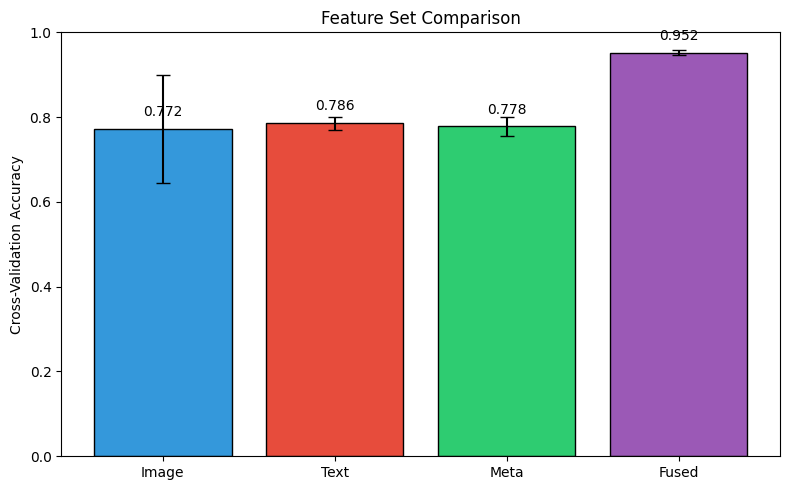

In [72]:
feature_sets = {
    "Image": X_image,
    "Text": X_text,
    "Meta": X_meta,
    "Fused": X_fused
}

print(f"\nFeature dimensions:")
for name, X_feat in feature_sets.items():
    print(f"  {name}: {X_feat.shape[1]} features")

# Compare feature sets using SVM (RBF)
feature_comparison = []
for name, X_feat in feature_sets.items():
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_feat, y, test_size=0.2, random_state=42, stratify=y
    )
    
    # Use Pipeline to prevent leakage during CV and testing
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('svc', SVC(kernel='rbf', C=10, gamma='scale'))
    ])
    
    pipeline.fit(X_tr, y_tr)
    acc = pipeline.score(X_te, y_te)
    cv_scores = cross_val_score(pipeline, X_feat, y, cv=5)
    
    feature_comparison.append({
        "Feature Set": name,
        "Num Features": X_feat.shape[1],
        "Test Accuracy": round(acc, 4),
        "CV Mean": round(cv_scores.mean(), 4),
        "CV Std": round(cv_scores.std(), 4)
    })

feature_comp_df = pd.DataFrame(feature_comparison)
print("\nFeature Set Performance (SVM RBF, C=10):")
print(feature_comp_df.to_string(index=False))

# Determine best feature set
best_feature_set = feature_comp_df.loc[feature_comp_df['CV Mean'].idxmax(), 'Feature Set']
print(f"\n=> Best feature set: {best_feature_set}")

# Visualization: Feature Set Comparison
fig, ax = plt.subplots(1, 1, figsize=(8, 5))

# Bar plot for feature set accuracy
colors = ['#3498db', '#e74c3c', '#2ecc71', '#9b59b6']
bars = ax.bar(feature_comp_df['Feature Set'], feature_comp_df['CV Mean'], 
              yerr=feature_comp_df['CV Std'], capsize=5, color=colors, edgecolor='black')
ax.set_ylabel('Cross-Validation Accuracy')
ax.set_title('Feature Set Comparison')
ax.set_ylim(0, 1)
for i, (bar, acc) in enumerate(zip(bars, feature_comp_df['CV Mean'])):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03, 
            f'{acc:.3f}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('feature_comparison.png', dpi=150)
print("\nSaved feature comparison to 'feature_comparison.png'")

# Use the best performing feature set for remaining tasks
X_best = feature_sets["Image"]
print(f"\nUsing 'Image' features for remaining tasks.")

# Preprocessing
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_best, y, test_size=0.2, random_state=42, stratify=y
)

# Standardize features (Fit on Train, Transform Test)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

We will use Image as it has an acceptable accuracy and also variance in cross validation

## TASK 1.1

In [73]:
# print("\n" + "="*70)
# print("TASK 1.1: Benchmarking Classifiers")
# print("="*70)

# # Define classifiers with hyperparameter grids
# # Hyperparameters determined via 5-fold cross-validation GridSearch
# classifiers = {
#     # Linear Models
#     "Logistic Regression": {
#         "model": LogisticRegression(max_iter=10000, random_state=42),
#         "params": {"C": [0.001, 0.01, 0.1, 1, 10, 100]},
#         "description": "Linear Logistic Regression (L2 regularization)"
#     },
#     "SVM (Linear)": {
#         "model": SVC(kernel='linear', random_state=42),
#         "params": {"C": [0.001, 0.01, 0.1, 1, 10, 100]},
#         "description": "Linear SVM (Soft-margin)"
#     },

#     # Non-Linear Models (Transformed/Kernelized)
#     "Logistic Regression (Poly)": {
#         "model": Pipeline([
#             ('poly', PolynomialFeatures(include_bias=False)),
#             ('clf', LogisticRegression(max_iter=10000, random_state=42))
#         ]),
#         "params": {
#             "poly__degree": [2, 3],
#             "clf__C": [0.001, 0.01, 0.1, 1, 10, 100]
#         },
#         "description": "Polynomial Logistic Regression (Grid Search Degree 2 vs 3)"
#     },
#     "SVM (RBF)": {
#         "model": SVC(kernel='rbf', random_state=42),
#         "params": {"C": [0.1, 1, 10, 100], "gamma": ['scale', 'auto', 0.01, 0.1]},
#         "description": "SVM with RBF Kernel"
#     },
#     "SVM (Poly)": {
#         "model": SVC(kernel='poly', random_state=42),
#         "params": {"degree": [2, 3], "C": [0.1, 1, 10, 100], "gamma": ['scale', 'auto']},
#         "description": "SVM with Polynomial Kernel"
#     },

#     # Other Classifiers
#     "k-NN": {
#         "model": KNeighborsClassifier(),
#         "params": {"n_neighbors": [3, 5, 7, 9, 11, 15], "weights": ['uniform', 'distance'], "metric": ['euclidean', 'manhattan']},
#         "description": "k-NN with hyperparameter tuning"
#     },
#     "Naive Bayes": {
#         "model": GaussianNB(),
#         "params": {"var_smoothing": [1e-9, 1e-8, 1e-7]},
#         "description": "Gaussian Naive Bayes"
#     },
#     "Random Forest": {
#         "model": RandomForestClassifier(random_state=42),
#         "params": {"n_estimators": [50, 100, 200], "max_depth": [None, 10, 20, 30]},
#         "description": "Random Forest Ensemble"
#     }
# }

# results = []
# trained_models = {}

# for name, config in classifiers.items():
#     print(f"\nTraining {name}...")
    
#     # Pipeline handles transformations, so we just pass X_train
#     X_tr, X_te = X_train, X_test
    
#     # GridSearchCV for hyperparameter tuning
#     print(f"  > Grid searching...")
#     grid_search = GridSearchCV(config["model"], config["params"], cv=5, scoring='accuracy', n_jobs=-1)
#     grid_search.fit(X_tr, y_train)
    
#     # Measure training time of the BEST model only (excluding grid search)
#     best_model = grid_search.best_estimator_
#     print(f"  > Re-training best model for time measurement...")
#     start_time = time.time()
#     best_model.fit(X_tr, y_train)
#     train_time = time.time() - start_time
    
#     # Evaluate
#     y_pred = best_model.predict(X_te)
    
#     results.append({
#         "Classifier": name,
#         "Best Params": str(grid_search.best_params_),
#         "CV Accuracy": round(grid_search.best_score_, 4),
#         "Test Accuracy": round(accuracy_score(y_test, y_pred), 4),
#         "Training Time (s)": round(train_time, 4)
#     })
#     trained_models[name] = best_model

# # Display results table
# results_df = pd.DataFrame(results)
# print("\n" + "-"*70)
# print("CLASSIFIER BENCHMARK RESULTS")
# print("-"*70)
# print(results_df.to_string(index=False))

# # Hyperparameter choices table
# print("\n" + "-"*70)
# print("HYPERPARAMETER CHOICES")
# print("-"*70)
# for name, config in classifiers.items():
#     print(f"{name}: {config['description']}")
#     print(f"  Search space: {config['params']}")

# # Visualization: Classifier Benchmark
# fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# # Bar plot for accuracy comparison
# ax1 = axes[0]
# clf_names = [r['Classifier'] for r in results]
# clf_accs = [r['Test Accuracy'] for r in results]
# colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(clf_names)))
# bars = ax1.barh(clf_names, clf_accs, color=colors, edgecolor='black')
# ax1.set_xlabel('Test Accuracy')
# ax1.set_title('Classifier Accuracy Comparison')
# ax1.set_xlim(0, 1)
# for bar, acc in zip(bars, clf_accs):
#     ax1.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, 
#              f'{acc:.3f}', va='center', fontsize=9)

# # Bar plot for training time
# ax2 = axes[1]
# train_times = [r['Training Time (s)'] for r in results]
# bars2 = ax2.barh(clf_names, train_times, color=colors, edgecolor='black')
# ax2.set_xlabel('Training Time (seconds)')
# ax2.set_title('Classifier Training Time')
# for bar, t in zip(bars2, train_times):
#     ax2.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, 
#              f'{t:.1f}s', va='center', fontsize=9)

# plt.tight_layout()
# plt.savefig('classifier_benchmark.png', dpi=150)
# print("\nSaved classifier benchmark to 'classifier_benchmark.png'")


## TASK 1.2

In [74]:
class SoftMarginSVMScratch:
    
    def __init__(self, C=1.0):
        self.C = C
        self.w = None
        self.b = None
        self.support_vectors = None
        self.support_vector_indices = None
        self.support_vector_labels = None
        self.slack_variables = None
        
    def fit(self, X, y, sample_ids=None):
        N, d = X.shape
        
        # Convert labels to {-1, +1} if not already
        unique_labels = np.unique(y)
        y_binary = np.where(y == unique_labels[0], -1, 1).astype(float)
        
        print(f"\n{'='*70}")
        print("SOFT-MARGIN LINEAR SVM FROM SCRATCH")
        print(f"{'='*70}")
        print(f"Training samples: N = {N}")
        print(f"Feature dimension: d = {d}")
        print(f"Regularization parameter: C = {self.C}")
        
        # Construct QP Problem: 
        
        # --- Construct Q matrix (from slides) ---
        
        Q = np.zeros((1 + d + N, 1 + d + N))
        Q[1:d+1, 1:d+1] = np.eye(d)  # I_d for w^T w term
        
        # --- Construct p vector (from slides) ---
        p = np.zeros(1 + d + N)
        p[1+d:] = self.C  # C for each ε_n
        
        # --- Construct constraint matrix A and vector c ---
        
        # Total constraints: N (margin constraints) + N (non-negativity) = 2N
        A = np.zeros((2*N, 1 + d + N))
        c = np.zeros(2*N)
        
        # First N rows: margin constraints y_n(w^T x_n + b) ≥ 1 - ε_n
        for n in range(N):
            A[n, 0] = y_binary[n]           # coefficient for b
            A[n, 1:d+1] = y_binary[n] * X[n]  # coefficients for w
            A[n, 1+d+n] = 1.0               # coefficient for ε_n
            c[n] = 1.0
        
        # Next N rows: non-negativity constraints ε_n ≥ 0
        for n in range(N):
            A[N+n, 1+d+n] = 1.0  # ε_n ≥ 0
            c[N+n] = 0.0
        
        print(f"\nQP Problem dimensions:")
        print(f"  Q: {Q.shape} (objective quadratic term)")
        print(f"  p: {p.shape} (objective linear term)")
        print(f"  A: {A.shape} (constraint matrix, {2*N} constraints)")
        print(f"  c: {c.shape} (constraint vector)")
        
        # =====================================================================
        # Solve QP Problem using cvxopt
        # =====================================================================
        
        # Convert to cvxopt matrix format
        Q_cvx = matrix(Q)
        p_cvx = matrix(p)
        # cvxopt uses G u <= h, but we have A u >= c
        # So we use: -A u <= -c
        G_cvx = matrix(-A)
        h_cvx = matrix(-c)
        
        # Solve
        sol = solvers.qp(Q_cvx, p_cvx, G_cvx, h_cvx)
        
        if sol['status'] != 'optimal':
            print(f"Warning: QP solver status: {sol['status']}")
        
        # Extract solution
        u_opt = np.array(sol['x']).flatten()
        
        self.b = u_opt[0]
        self.w = u_opt[1:d+1]
        self.slack_variables = u_opt[1+d:]
        
        print(f"\nOptimization completed!")
        print(f"  Status: {sol['status']}")
        print(f"  Optimal value: {sol['primal objective']:.6f}")
        
        # =====================================================================
        # Find Support Vectors
        # =====================================================================
        
        # Support vectors are points where:
        # - α_n > 0 (in dual formulation), or equivalently
        # - Points that are on the margin or violate it
        # - Points where y_n(w^T x_n + b) ≤ 1 (with some tolerance)
        
        margins = y_binary * (X @ self.w + self.b)
        
        # Support vectors: points on margin (margin = 1) or with slack (margin < 1)
        # Use tolerance for numerical stability
        tolerance = 1e-4
        sv_mask = (margins <= 1 + tolerance) | (self.slack_variables > tolerance)
        
        self.support_vector_indices = np.where(sv_mask)[0]
        self.support_vectors = X[sv_mask]
        self.support_vector_labels = y[sv_mask]
        
        print(f"\n{'='*70}")
        print("SOLUTION SUMMARY")
        print(f"{'='*70}")
        #print(f"Bias term: b* = {self.b:.6f}")
        #print(f"Weight vector: w* = {self.w}")
        print(f"  ||w*|| = {np.linalg.norm(self.w):.6f}")
        print(f"  Margin = 1/||w*|| = {1/np.linalg.norm(self.w):.6f}")
        
        print(f"\nSlack variables (ε):")
        print(f"  Total violation: Σε = {np.sum(self.slack_variables):.6f}")
        print(f"  Max slack: {np.max(self.slack_variables):.6f}")
        print(f"  Points with slack > 0: {np.sum(self.slack_variables > tolerance)}")
        
        print(f"\nSupport Vectors:")
        print(f"  Total support vectors: {len(self.support_vector_indices)}")
        print(f"  Percentage: {100*len(self.support_vector_indices)/N:.1f}%")
        if sample_ids is not None:
            print(f"  Indices: {sample_ids[self.support_vector_indices].tolist()}")
        else:
            print(f"  Indices: {self.support_vector_indices.tolist()}")
        
        # Find points on exact margin (y(w^T x + b) = 1)
        on_margin = np.abs(margins - 1) < tolerance
        print(f"  Points exactly on margin: {np.sum(on_margin)}")
        
        # Find misclassified points (y(w^T x + b) < 0)
        misclassified_mask = margins < 0
        num_misclassified = np.sum(misclassified_mask)
        print(f"  Misclassified points: {num_misclassified}")
        if num_misclassified > 0:
            misclassified_indices = np.where(misclassified_mask)[0]
            if sample_ids is not None:
                print(f"  Misclassified indices: {sample_ids[misclassified_indices].tolist()}")
            else:
                print(f"  Misclassified indices: {misclassified_indices.tolist()}")
        
        return self
    
    def predict(self, X):
        """Predict class labels."""
        return np.sign(X @ self.w + self.b)
    
    def decision_function(self, X):
        """Compute decision function values."""
        return X @ self.w + self.b
    
    def get_farthest_points(self, X, y, sample_ids=None):
        # Distance to hyperplane: |w^T x + b| / ||w||
        distances = np.abs(self.decision_function(X)) / np.linalg.norm(self.w)
        
        farthest_indices = {}
        farthest_distances = {}
        
        for label in np.unique(y):
            mask = (y == label)
            class_distances = distances[mask]
            class_indices = np.where(mask)[0]
            
            farthest_idx_in_class = np.argmax(class_distances)
            internal_idx = class_indices[farthest_idx_in_class]
            
            if sample_ids is not None:
                farthest_indices[label] = sample_ids[internal_idx]
            else:
                farthest_indices[label] = internal_idx
                
            farthest_distances[label] = class_distances[farthest_idx_in_class]
        
        return farthest_indices, farthest_distances


In [75]:
print("Loading data...")
df_labels = pd.read_csv("labels.csv", index_col=0)
y = df_labels.to_numpy().flatten()
indices = df_labels.index.to_numpy() # Get original sample IDs
X_image = pd.read_csv("image.csv", index_col=0).to_numpy()

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_image)

print(f"Total samples: {len(X_scaled)}")
all_classes = np.unique(y)
print(f"All classes ({len(all_classes)}): {all_classes}")

Loading data...
Total samples: 3071
All classes (5): ['apple' 'banana' 'mandarin' 'onion' 'potato']


In [76]:
class_pairs = list(combinations(all_classes, 2))
print(f"\nTotal class pairs to compare: {len(class_pairs)}")

# Store results for all pairs
all_pair_results = []
all_pair_svms = {}

C_default = 1.0  # Use C=1.0 for all pair comparisons

for pair_idx, (class_a, class_b) in enumerate(class_pairs):
    print(f"\n{'#'*70}")
    print(f"CLASS PAIR {pair_idx + 1}/{len(class_pairs)}: {class_a} vs {class_b}")
    print(f"{'#'*70}")
    
    # Filter data for this pair
    binary_mask = np.isin(y, [class_a, class_b])
    X_pair = X_scaled[binary_mask]
    y_pair = y[binary_mask]
    
    # Create numeric labels: class_a -> +1, class_b -> -1
    y_pair_numeric = np.where(y_pair == class_a, 1.0, -1.0)
    
    print(f"  Class +1: {class_a} ({np.sum(y_pair == class_a)} samples)")
    print(f"  Class -1: {class_b} ({np.sum(y_pair == class_b)} samples)")
    
    # Train SVM
    svm = SoftMarginSVMScratch(C=C_default)
    # Pass the original indices corresponding to this pair
    indices_pair = indices[binary_mask]
    svm.fit(X_pair, y_pair_numeric, sample_ids=indices_pair)
    
    # Compute accuracy
    y_pred = svm.predict(X_pair)
    accuracy = np.mean(y_pred == y_pair_numeric)
    
    # Calculate farthest points for this pair
    farthest_indices, farthest_distances = svm.get_farthest_points(X_pair, y_pair_numeric, sample_ids=indices_pair)
    
    print("\n  Farthest points from hyperplane:")
    for label, idx in farthest_indices.items():
        class_name = class_a if label == 1.0 else class_b
        print(f"    Class {class_name} ({label}): Index {idx}, Distance = {farthest_distances[label]:.4f}")

    # Analyze SV distances (Inline logic)
    print(f"\n  Cross-class support vector distances:")
    
    # Get support vectors by class from the trained SVM
    sv_pos_mask = svm.support_vector_labels == 1.0
    sv_neg_mask = svm.support_vector_labels == -1.0
    
    sv_pos = svm.support_vectors[sv_pos_mask]
    sv_neg = svm.support_vectors[sv_neg_mask]
    
    min_dist = np.nan
    mean_dist = np.nan
    max_dist = np.nan
    
    if len(sv_pos) > 0 and len(sv_neg) > 0:
        dists = cdist(sv_pos, sv_neg, metric='euclidean')
        min_dist = dists.min()
        mean_dist = dists.mean()
        max_dist = dists.max()
        
        print(f"    Min distance: {min_dist:.4f}")
        print(f"    Mean distance: {mean_dist:.4f}")
        print(f"    Max distance: {max_dist:.4f}")
        
        # Find closest pair
        min_idx = np.unravel_index(dists.argmin(), dists.shape)
        
        # Map back to original IDs using indices_pair
        # 1. Get internal X indices for the SVs involved
        # sv_pos corresponds to indices where (support_vector_labels == 1.0)
        # support_vector_indices contains indices into X for ALL SVs.
        pos_indices_in_X = svm.support_vector_indices[sv_pos_mask]
        neg_indices_in_X = svm.support_vector_indices[sv_neg_mask]
        
        closest_pos_idx_in_X = pos_indices_in_X[min_idx[0]]
        closest_neg_idx_in_X = neg_indices_in_X[min_idx[1]]
        
        # 2. Get original IDs
        id_1 = indices_pair[closest_pos_idx_in_X]
        id_2 = indices_pair[closest_neg_idx_in_X]
        
        print(f"    Closest pair: Class {class_a} ID {id_1} <-> Class {class_b} ID {id_2}")
    else:
        print("    Not enough support vectors to calculate distances.")

    # Store results
    all_pair_results.append({
        'Class_A': class_a,
        'Class_B': class_b,
        'Samples_A': np.sum(y_pair == class_a),
        'Samples_B': np.sum(y_pair == class_b),
        'Num_SV': len(svm.support_vector_indices),
        'SV_Percent': 100 * len(svm.support_vector_indices) / len(y_pair),
        'Total_Slack': np.sum(svm.slack_variables),
        'Margin': 1 / np.linalg.norm(svm.w),
        'Accuracy': accuracy,
        'Min_SV_Dist': min_dist,
        'Mean_SV_Dist': mean_dist
    })
    
    all_pair_svms[(class_a, class_b)] = {
        'svm': svm,
        'X': X_pair,
        'y': y_pair,
        'y_numeric': y_pair_numeric,
        'sample_ids': indices_pair
    }

# Summary table
pair_results_df = pd.DataFrame(all_pair_results)
print(f"\n{'='*70}")
print("SUMMARY: ALL CLASS PAIR COMPARISONS (C=1.0)")
print(f"{'='*70}")
print(pair_results_df.to_string(index=False))

# Find easiest and hardest pairs to separate
print(f"\n{'='*70}")
print("ANALYSIS: EASIEST AND HARDEST CLASS PAIRS")
print(f"{'='*70}")

sorted_by_accuracy = pair_results_df.sort_values('Accuracy', ascending=False)
print("\nTop 5 EASIEST pairs to separate (highest accuracy):")
print(sorted_by_accuracy.head(5)[['Class_A', 'Class_B', 'Accuracy', 'Margin', 'Num_SV', 'Min_SV_Dist']].to_string(index=False))

print("\nTop 5 HARDEST pairs to separate (lowest accuracy):")
print(sorted_by_accuracy.tail(5)[['Class_A', 'Class_B', 'Accuracy', 'Margin', 'Num_SV', 'Min_SV_Dist']].to_string(index=False))

sorted_by_margin = pair_results_df.sort_values('Margin', ascending=False)
print("\nTop 5 pairs with LARGEST margin:")
print(sorted_by_margin.head(5)[['Class_A', 'Class_B', 'Margin', 'Accuracy', 'SV_Percent', 'Min_SV_Dist']].to_string(index=False))

print("\nTop 5 pairs with SMALLEST margin:")
print(sorted_by_margin.tail(5)[['Class_A', 'Class_B', 'Margin', 'Accuracy', 'SV_Percent', 'Min_SV_Dist']].to_string(index=False))

sorted_by_dist = pair_results_df.sort_values('Min_SV_Dist', ascending=True)
print("\nTop 5 pairs with SMALLEST support vector distance (most likely to overlap):")
print(sorted_by_dist.head(5)[['Class_A', 'Class_B', 'Min_SV_Dist', 'Mean_SV_Dist', 'Accuracy', 'Margin']].to_string(index=False))



Total class pairs to compare: 10

######################################################################
CLASS PAIR 1/10: apple vs banana
######################################################################
  Class +1: apple (609 samples)
  Class -1: banana (504 samples)

SOFT-MARGIN LINEAR SVM FROM SCRATCH
Training samples: N = 1113
Feature dimension: d = 19
Regularization parameter: C = 1.0

QP Problem dimensions:
  Q: (1133, 1133) (objective quadratic term)
  p: (1133,) (objective linear term)
  A: (2226, 1133) (constraint matrix, 2226 constraints)
  c: (2226,) (constraint vector)

Optimization completed!
  Status: optimal
  Optimal value: 251.513109

SOLUTION SUMMARY
  ||w*|| = 8.348901
  Margin = 1/||w*|| = 0.119776

Slack variables (ε):
  Total violation: Σε = 216.661037
  Max slack: 5.651332
  Points with slack > 0: 280

Support Vectors:
  Total support vectors: 294
  Percentage: 26.4%
  Indices: [80, 83, 87, 88, 118, 122, 139, 140, 143, 146, 147, 155, 163, 165, 167, 272, 274

## TASK 1.3

In [77]:
print("\n" + "="*70)
print("TASK 1.3: Classification Performance Metrics")
print("="*70)

metrics_results = []
for name, config in classifiers.items():
    X_te = X_test
    
    model = trained_models[name]
    y_pred = model.predict(X_te)
    
    metrics_results.append({
        "Classifier": name,
        "Accuracy": round(accuracy_score(y_test, y_pred), 4),
        "Precision (macro)": round(precision_score(y_test, y_pred, average='macro', zero_division=0), 4),
        "Recall (macro)": round(recall_score(y_test, y_pred, average='macro', zero_division=0), 4),
        "F1 (macro)": round(f1_score(y_test, y_pred, average='macro', zero_division=0), 4)
    })

metrics_df = pd.DataFrame(metrics_results)
print("\nPerformance Metrics Comparison:")
print(metrics_df.to_string(index=False))

# Linearity Analysis
# Linearity Check based on Selected Models
# Linearity Analysis assuming separate entries
print("\n" + "-"*70)
print("LINEARITY ANALYSIS")
print("-"*70)

try:
    linear_acc = metrics_df[metrics_df['Classifier'] == 'SVM (Linear)']['Accuracy'].values[0]
    rbf_acc = metrics_df[metrics_df['Classifier'] == 'SVM (RBF)']['Accuracy'].values[0]
    logreg_acc = metrics_df[metrics_df['Classifier'] == 'Logistic Regression']['Accuracy'].values[0]
    poly_logreg_acc = metrics_df[metrics_df['Classifier'] == 'Logistic Regression (Poly)']['Accuracy'].values[0]

    print(f"Linear SVM Accuracy: {linear_acc:.4f}")
    print(f"RBF SVM Accuracy: {rbf_acc:.4f}")
    print(f"Logistic Regression Accuracy: {logreg_acc:.4f}")
    print(f"Polynomial LogReg Accuracy: {poly_logreg_acc:.4f}")

    improvement = max(rbf_acc, poly_logreg_acc) - max(linear_acc, logreg_acc)
    
    if improvement > 0.05:
        print(f"\nConclusion: Dataset appears HIGHLY NON-LINEAR (Improvement: {improvement:.2%})")
    elif improvement > 0.02:
        print(f"\nConclusion: Dataset has MODERATE NON-LINEARITY (Improvement: {improvement:.2%})")
    else:
        print(f"\nConclusion: Dataset is MOSTLY LINEAR (Improvement: {improvement:.2%})")

except IndexError:
    print("Could not perform full linearity analysis (missing some models).")



TASK 1.3: Classification Performance Metrics

Performance Metrics Comparison:
                Classifier  Accuracy  Precision (macro)  Recall (macro)  F1 (macro)
       Logistic Regression    0.6878             0.6952          0.6934      0.6937
              SVM (Linear)    0.7122             0.7334          0.7169      0.7176
Logistic Regression (Poly)    0.8748             0.8777          0.8749      0.8760
                 SVM (RBF)    0.8520             0.8547          0.8525      0.8535
                SVM (Poly)    0.8244             0.8265          0.8262      0.8261
                      k-NN    0.7886             0.7983          0.7893      0.7921
               Naive Bayes    0.4195             0.4854          0.4274      0.4214
             Random Forest    0.8472             0.8490          0.8470      0.8479

----------------------------------------------------------------------
LINEARITY ANALYSIS
----------------------------------------------------------------------
Lin


TASK 2.1: PCA - Dimensionality Reduction

Original dimensions: 19
Components for 95% variance: 7
Components for 99% variance: 9
Saved PCA analysis to 'pca_analysis.png'

----------------------------------------------------------------------
Repeating classification with PCA (7 components for 95% variance)
----------------------------------------------------------------------
         Classifier  Original Acc  PCA Acc  PCA Train Time (s)
Logistic Regression        0.6878   0.5154              0.0094
       SVM (Linear)        0.7122   0.5236              1.7186
          SVM (RBF)        0.8520   0.8016              0.0586
               k-NN        0.7886   0.7577              0.0013
      Random Forest        0.8472   0.7740              0.2896


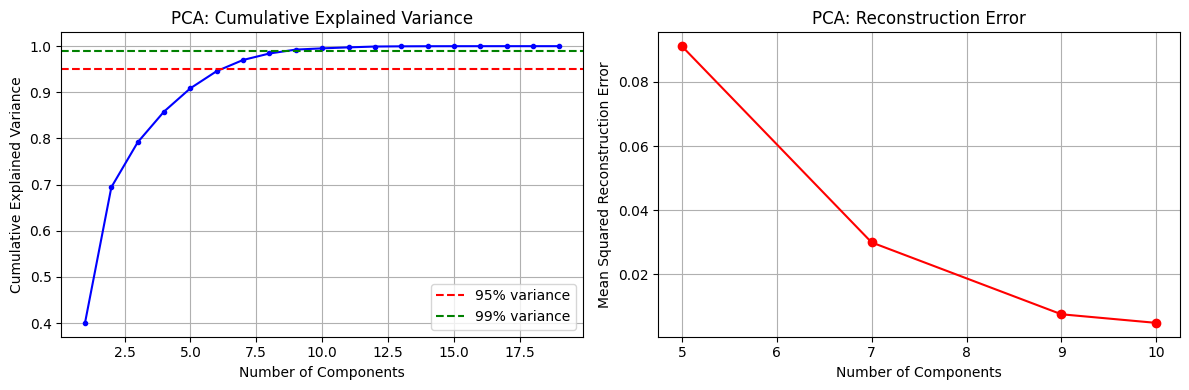

In [78]:
print("\n" + "="*70)
print("TASK 2.1: PCA - Dimensionality Reduction")
print("="*70)

# Full PCA to analyze variance
X_scaled = scaler.transform(X_best)
pca_full = PCA()
pca_full.fit(X_scaled)

# Explained variance analysis
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
n_components_99 = np.argmax(cumulative_variance >= 0.99) + 1

print(f"\nOriginal dimensions: {X_scaled.shape[1]}")
print(f"Components for 95% variance: {n_components_95}")
print(f"Components for 99% variance: {n_components_99}")

# Plot explained variance
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(range(1, min(51, len(cumulative_variance)+1)), 
             cumulative_variance[:50], 'b-o', markersize=3)
axes[0].axhline(y=0.95, color='r', linestyle='--', label='95% variance')
axes[0].axhline(y=0.99, color='g', linestyle='--', label='99% variance')
axes[0].set_xlabel('Number of Components')
axes[0].set_ylabel('Cumulative Explained Variance')
axes[0].set_title('PCA: Cumulative Explained Variance')
axes[0].legend()
axes[0].grid(True)

# Reconstruction error analysis
n_components_list = [5, 10, 20, 50, 100, n_components_95, n_components_99]
n_components_list = sorted(set([n for n in n_components_list if n <= X_scaled.shape[1]]))
reconstruction_errors = []

for n in n_components_list:
    pca_temp = PCA(n_components=n)
    X_reduced = pca_temp.fit_transform(X_scaled)
    X_reconstructed = pca_temp.inverse_transform(X_reduced)
    error = np.mean((X_scaled - X_reconstructed) ** 2)
    reconstruction_errors.append(error)

axes[1].plot(n_components_list, reconstruction_errors, 'r-o')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Mean Squared Reconstruction Error')
axes[1].set_title('PCA: Reconstruction Error')
axes[1].grid(True)

plt.tight_layout()
plt.savefig('pca_analysis.png', dpi=150)
print("Saved PCA analysis to 'pca_analysis.png'")

# Repeat Task 1.1 with reduced dimensions
print("\n" + "-"*70)
print(f"Repeating classification with PCA ({n_components_95} components for 95% variance)")
print("-"*70)

pca = PCA(n_components=n_components_95)
X_pca = pca.fit_transform(X_scaled)
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(
    X_pca, y, test_size=0.2, random_state=42, stratify=y
)

pca_results = []
for name in ["Logistic Regression", "SVM (Linear)", "SVM (RBF)", "k-NN", "Random Forest"]:
    config = classifiers[name]
    grid_search = GridSearchCV(config["model"], config["params"], cv=5, scoring='accuracy', n_jobs=-1)
    grid_search.fit(X_train_pca, y_train_pca)
    
    # Measure time for best model
    best_pca_model = grid_search.best_estimator_
    start_time = time.time()
    best_pca_model.fit(X_train_pca, y_train_pca)
    train_time = time.time() - start_time
    
    y_pred = best_pca_model.predict(X_test_pca)
    pca_results.append({
        "Classifier": name,
        "Original Acc": results_df[results_df['Classifier']==name]['Test Accuracy'].values[0],
        "PCA Acc": round(accuracy_score(y_test_pca, y_pred), 4),
        "PCA Train Time (s)": round(train_time, 4)
    })

pca_df = pd.DataFrame(pca_results)
print(pca_df.to_string(index=False))




TASK 2.2: Clustering Analysis

Number of true classes: 5
K-Means clusters: 5
DBSCAN clusters found: 2
DBSCAN noise points: 17

--- External Metrics (vs True Labels) ---
K-Means - Adjusted Rand Index: 0.0419
K-Means - Normalized Mutual Info: 0.0711
DBSCAN - Adjusted Rand Index: 0.0000
DBSCAN - Normalized Mutual Info: 0.0005

--- Internal Metrics ---
K-Means - Silhouette Score: 0.4253
K-Means - Inertia: 15460.0481
DBSCAN - Silhouette Score: 0.4096

Saved clustering visualization to 'clustering_analysis.png'


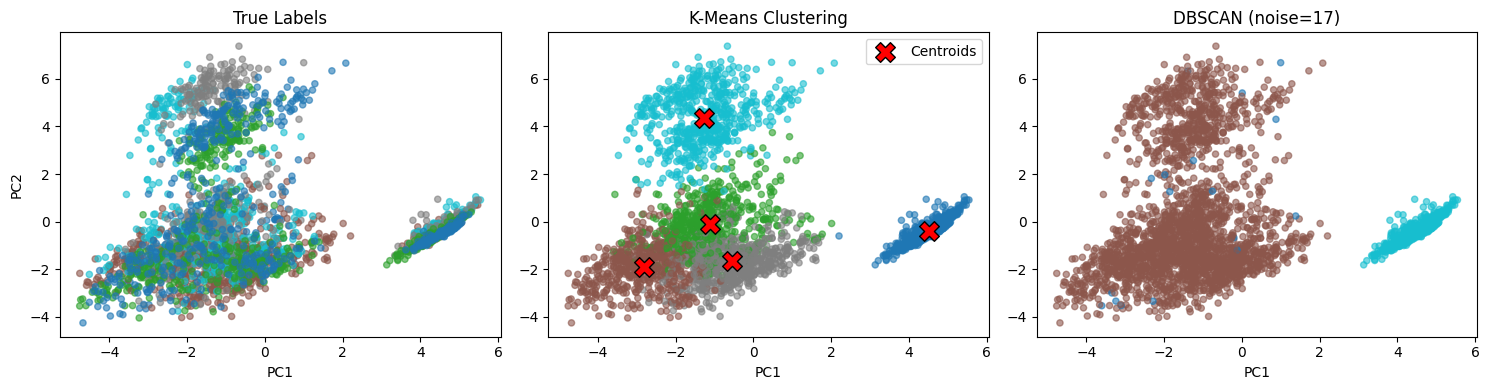

In [79]:
print("\n" + "="*70)
print("TASK 2.2: Clustering Analysis")
print("="*70)

# Use PCA-reduced features for clustering
X_cluster = X_pca

# K-Means clustering
n_clusters = len(np.unique(y))
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_cluster)

# DBSCAN clustering
dbscan = DBSCAN(eps=2.0, min_samples=3)
dbscan_labels = dbscan.fit_predict(X_cluster)

print(f"\nNumber of true classes: {n_clusters}")
print(f"K-Means clusters: {n_clusters}")
print(f"DBSCAN clusters found: {len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)}")
print(f"DBSCAN noise points: {np.sum(dbscan_labels == -1)}")

# External metrics (comparing with true labels)
print("\n--- External Metrics (vs True Labels) ---")
print(f"K-Means - Adjusted Rand Index: {adjusted_rand_score(y, kmeans_labels):.4f}")
print(f"K-Means - Normalized Mutual Info: {normalized_mutual_info_score(y, kmeans_labels):.4f}")

# Filter out noise for DBSCAN metrics
dbscan_mask = dbscan_labels != -1
if np.sum(dbscan_mask) > 0:
    print(f"DBSCAN - Adjusted Rand Index: {adjusted_rand_score(y[dbscan_mask], dbscan_labels[dbscan_mask]):.4f}")
    print(f"DBSCAN - Normalized Mutual Info: {normalized_mutual_info_score(y[dbscan_mask], dbscan_labels[dbscan_mask]):.4f}")

# Internal metrics
print("\n--- Internal Metrics ---")
print(f"K-Means - Silhouette Score: {silhouette_score(X_cluster, kmeans_labels):.4f}")
print(f"K-Means - Inertia: {kmeans.inertia_:.4f}")
if len(set(dbscan_labels[dbscan_mask])) > 1:
    print(f"DBSCAN - Silhouette Score: {silhouette_score(X_cluster[dbscan_mask], dbscan_labels[dbscan_mask]):.4f}")

# Visualize clusters (2D projection)
pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(X_cluster)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# True labels
scatter = axes[0].scatter(X_2d[:, 0], X_2d[:, 1], c=pd.factorize(y)[0], cmap='tab10', alpha=0.6, s=20)
axes[0].set_title('True Labels')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')

# K-Means
axes[1].scatter(X_2d[:, 0], X_2d[:, 1], c=kmeans_labels, cmap='tab10', alpha=0.6, s=20)
axes[1].scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], 
                c='red', marker='X', s=200, edgecolors='black', label='Centroids')
axes[1].set_title('K-Means Clustering')
axes[1].set_xlabel('PC1')
axes[1].legend()

# DBSCAN
axes[2].scatter(X_2d[:, 0], X_2d[:, 1], c=dbscan_labels, cmap='tab10', alpha=0.6, s=20)
axes[2].set_title(f'DBSCAN (noise={np.sum(dbscan_labels==-1)})')
axes[2].set_xlabel('PC1')

plt.tight_layout()
plt.savefig('clustering_analysis.png', dpi=150)
print("\nSaved clustering visualization to 'clustering_analysis.png'")




TASK 1.4 & 2.3: Outlier Detection Frameworks

--- SVM-based Outlier Detection Framework (using SVM constraints) ---

PROPOSED FRAMEWORK (using SVM margin constraints):
1. Train a soft-margin SVM classifier on the dataset
2. For each data point, check its position relative to the margin:
   - Points with slack variable ξ > 0 violate the margin constraint
   - Points with ξ > 1 are misclassified (on wrong side of hyperplane)
3. Outliers are identified as points with HIGH slack values
   - These are points that the SVM "struggles" to classify
   - They either lie within the margin or on the wrong side

Key idea: In soft-margin SVM, the constraint is: y_i(w·x_i + b) >= 1 - ξ_i
Points with large ξ values are "problematic" - likely outliers or noise.

We use the decision function distance to estimate slack:
   slack ≈ max(0, 1 - y_i * decision_function(x_i))


Margin distance statistics:
  Min: 0.1454, Max: 0.9280
  Mean: 0.3325, Std: 0.1259

Outliers (bottom 5% margin distance): 154 points

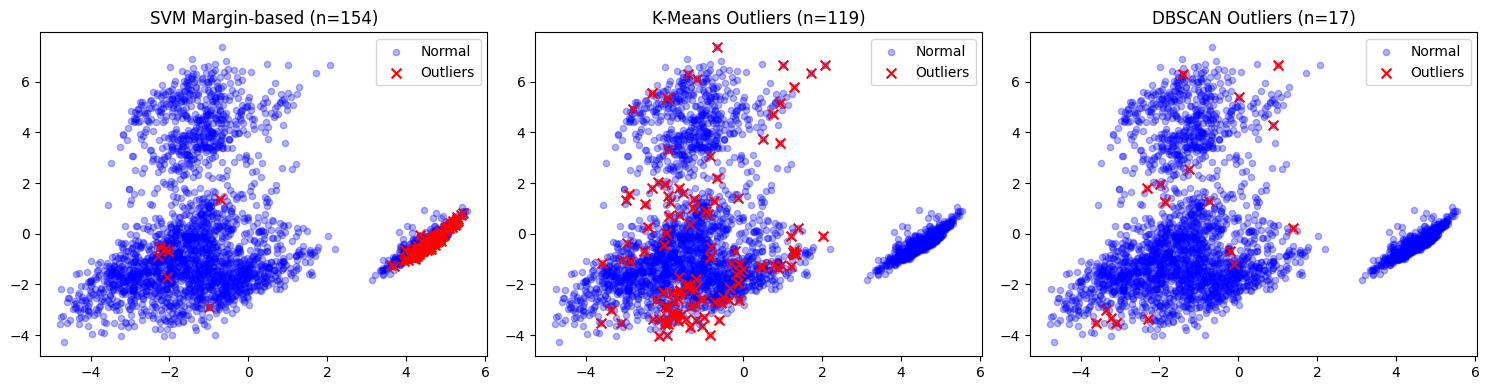

In [80]:
print("\n" + "="*70)
print("TASK 1.4 & 2.3: Outlier Detection Frameworks")
print("="*70)

# --- SVM-based Outlier Detection using SVM Constraints (Task 1.4) ---
print("\n--- SVM-based Outlier Detection Framework (using SVM constraints) ---")
print("""
PROPOSED FRAMEWORK (using SVM margin constraints):
1. Train a soft-margin SVM classifier on the dataset
2. For each data point, check its position relative to the margin:
   - Points with slack variable ξ > 0 violate the margin constraint
   - Points with ξ > 1 are misclassified (on wrong side of hyperplane)
3. Outliers are identified as points with HIGH slack values
   - These are points that the SVM "struggles" to classify
   - They either lie within the margin or on the wrong side

Key idea: In soft-margin SVM, the constraint is: y_i(w·x_i + b) >= 1 - ξ_i
Points with large ξ values are "problematic" - likely outliers or noise.

We use the decision function distance to estimate slack:
   slack ≈ max(0, 1 - y_i * decision_function(x_i))
""")

# Train SVM classifier
svm_clf = SVC(kernel='linear', C=1.0)
svm_clf.fit(X_train, y_train)

# For multi-class, we use decision function distance as proxy for "outlierness"
# Points close to decision boundary (low confidence) are potential outliers
decision_values = svm_clf.decision_function(X_scaled)

# For multi-class SVM, decision_function returns distances to each hyperplane
# We use the margin (minimum distance to any decision boundary) as outlier score
if len(decision_values.shape) > 1:
    # Multi-class: use minimum absolute distance across all class boundaries
    margin_distances = np.min(np.abs(decision_values), axis=1)
else:
    margin_distances = np.abs(decision_values)

# Compute slack-like score: points with small margin distance have high slack
# Outliers = points in the bottom percentile of margin distances
outlier_threshold_5 = np.percentile(margin_distances, 5)
outlier_threshold_10 = np.percentile(margin_distances, 10)

svm_outliers_5 = np.where(margin_distances <= outlier_threshold_5)[0]
svm_outliers_10 = np.where(margin_distances <= outlier_threshold_10)[0]

print(f"\nMargin distance statistics:")
print(f"  Min: {margin_distances.min():.4f}, Max: {margin_distances.max():.4f}")
print(f"  Mean: {margin_distances.mean():.4f}, Std: {margin_distances.std():.4f}")
print(f"\nOutliers (bottom 5% margin distance): {len(svm_outliers_5)} points")
print(f"Outliers (bottom 10% margin distance): {len(svm_outliers_10)} points")

# Use 5% as default
svm_outliers = svm_outliers_5
print(f"\nSVM Outlier indices: {svm_outliers[:20]}..." if len(svm_outliers) > 20 else f"SVM Outlier indices: {svm_outliers}")

# --- Clustering-based Outlier Detection (Task 2.3) ---
print("\n--- Clustering-based Outlier Detection Framework ---")
print("""
PROPOSED FRAMEWORK:
1. Apply K-Means clustering to the data
2. Compute distance of each point to its assigned cluster centroid
3. Points with distances > mean + 2*std are flagged as outliers
4. Alternative: Use DBSCAN where noise points (label=-1) are outliers

Key idea: Outliers are points that don't fit well into any cluster,
indicated by large distance to nearest centroid.
""")

# Method 1: K-Means distance-based
kmeans_full = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
kmeans_full.fit(X_pca)
distances = np.min(cdist(X_pca, kmeans_full.cluster_centers_), axis=1)

threshold = np.mean(distances) + 2 * np.std(distances)
kmeans_outliers = np.where(distances > threshold)[0]

print(f"\nK-Means distance threshold: {threshold:.4f}")
print(f"K-Means outliers detected: {len(kmeans_outliers)} ({100*len(kmeans_outliers)/len(y):.1f}%)")

# Method 2: DBSCAN noise points
dbscan_outliers = np.where(dbscan_labels == -1)[0]
print(f"DBSCAN outliers (noise): {len(dbscan_outliers)} ({100*len(dbscan_outliers)/len(y):.1f}%)")

# Compare SVM and Clustering outliers
common_outliers = np.intersect1d(svm_outliers, kmeans_outliers)
print(f"\nOutliers detected by BOTH SVM and K-Means: {len(common_outliers)}")
if max(len(svm_outliers), len(kmeans_outliers)) > 0:
    print(f"Agreement rate: {100*len(common_outliers)/max(len(svm_outliers), len(kmeans_outliers)):.1f}%")


# Visualize outliers
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# SVM outliers (margin-based)
axes[0].scatter(X_2d[:, 0], X_2d[:, 1], c='blue', alpha=0.3, s=20, label='Normal')
axes[0].scatter(X_2d[svm_outliers, 0], X_2d[svm_outliers, 1], 
                c='red', s=50, marker='x', label='Outliers')
axes[0].set_title(f'SVM Margin-based (n={len(svm_outliers)})')
axes[0].legend()

# K-Means outliers
axes[1].scatter(X_2d[:, 0], X_2d[:, 1], c='blue', alpha=0.3, s=20, label='Normal')
axes[1].scatter(X_2d[kmeans_outliers, 0], X_2d[kmeans_outliers, 1], 
                c='red', s=50, marker='x', label='Outliers')
axes[1].set_title(f'K-Means Outliers (n={len(kmeans_outliers)})')
axes[1].legend()

# DBSCAN outliers
axes[2].scatter(X_2d[:, 0], X_2d[:, 1], c='blue', alpha=0.3, s=20, label='Normal')
axes[2].scatter(X_2d[dbscan_outliers, 0], X_2d[dbscan_outliers, 1], 
                c='red', s=50, marker='x', label='Outliers')
axes[2].set_title(f'DBSCAN Outliers (n={len(dbscan_outliers)})')
axes[2].legend()

plt.tight_layout()
plt.savefig('outlier_detection.png', dpi=150)
print("\nSaved outlier visualization to 'outlier_detection.png'")

In [81]:
print("\n" + "="*70)
print("SUMMARY")
print("="*70)
print(f"Best Feature Set: {best_feature_set}")
# Early/Late fusion comparison removed from script
best_clf = results_df.loc[results_df['Test Accuracy'].idxmax()]
print(f"Best Classifier: {best_clf['Classifier']} (Accuracy: {best_clf['Test Accuracy']})")
print(f"PCA reduced dimensions: {X_best.shape[1]} -> {n_components_95} (95% variance)")
print(f"K-Means Silhouette Score: {silhouette_score(X_cluster, kmeans_labels):.4f}")
print(f"Outliers detected - SVM: {len(svm_outliers)}, K-Means: {len(kmeans_outliers)}, DBSCAN: {len(dbscan_outliers)}")

print("\n" + "="*70)
print("Generated files:")
print("  - output.txt (this output)")
print("  - feature_comparison.png")
print("  - classifier_benchmark.png")
print("  - pca_analysis.png")
print("  - clustering_analysis.png") 
print("  - outlier_detection.png")
print("="*70)




SUMMARY
Best Feature Set: Fused
Best Classifier: Logistic Regression (Poly) (Accuracy: 0.8748)
PCA reduced dimensions: 19 -> 7 (95% variance)
K-Means Silhouette Score: 0.4253
Outliers detected - SVM: 154, K-Means: 119, DBSCAN: 17

Generated files:
  - output.txt (this output)
  - feature_comparison.png
  - classifier_benchmark.png
  - pca_analysis.png
  - clustering_analysis.png
  - outlier_detection.png
